# Preprocessing and Pipelines with Scikit-Learn

In this notebook we build complete machine learning pipelines.

We demonstrate:

- Handling missing data
- Encoding categorical features
- Feature scaling
- Building pipelines
- Evaluating multiple models

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [2]:
# Load Dataset

df = pd.read_csv("../data/titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Feature Selection

features = ["Pclass","Age","Fare","Sex","Embarked"]

X = df[features]
y = df["Survived"]

In [4]:
# Train/Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
# Separate Feature Types

numeric_features = ["Age","Fare"]
categorical_features = ["Pclass","Sex","Embarked"]

In [6]:
# Preprocessing Pipelines

# Numeric Pipeline

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [7]:
# Combine Using ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [8]:
# Create Full Pipeline (Logistic Regression)
log_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

In [9]:
# Train Model
log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('model', LogisticRegression())])

In [10]:
# Predict
log_pred = log_pipeline.predict(X_test)

In [11]:
# Accuracy
log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", log_acc)

Logistic Regression Accuracy: 0.7932960893854749


In [12]:
# KNN Pipeline
knn_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

In [13]:
# Train & Evaluate KNN
knn_pipeline.fit(X_train, y_train)

knn_pred = knn_pipeline.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 0.7877094972067039


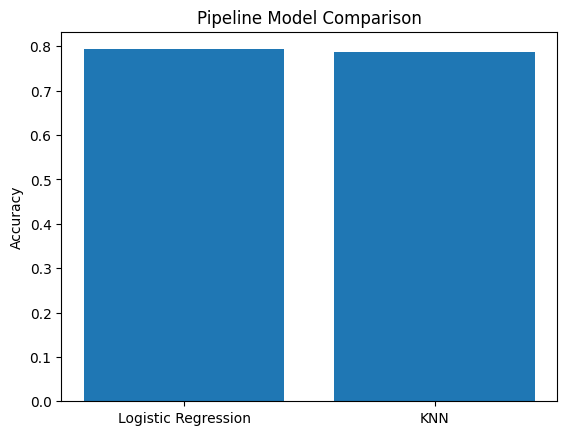

In [14]:
# Compare Models
models = ["Logistic Regression","KNN"]
scores = [log_acc, knn_acc]

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Pipeline Model Comparison")

plt.show()

## Key Insights

- Pipelines allow combining preprocessing and modeling steps.
- This ensures consistent data transformation during training and testing.
- ColumnTransformer enables handling different feature types.
- Pipelines improve code readability and reduce errors.
- This approach is closer to production-level machine learning workflows.